# Исследовательский анализ бронирований билетов Яндекс Афиша

Автор: Алексей Поляков\
Дата: 01.07.2026


## Цель проекта
Изучить динамику бронирований билетов с июня по октябрь 2024 года, выявить сезонные изменения спроса, определить популярные типы мероприятий, регионы и партнёров, а также сравнить поведение пользователей мобильных и стационарных устройств.

## Задачи
- Загрузить и изучить данные.
- Провести предобработку.
- Привести выручку к рублям.
- Выполнить исследовательский анализ по сезонам, дням и категориям.
- Проверить статистические гипотезы.
- Сформулировать выводы и рекомендации.

## Данные
- Таблица `final_tickets_orders_df.csv` — заказы билетов.

    `order_id` — уникальный идентификатор заказа.\
    `user_id` — уникальный идентификатор пользователя.\
    `created_dt_msk` — дата создания заказа (московское время).\
    `created_ts_msk` — дата и время создания заказа (московское время).\
    `event_id` — идентификатор мероприятия из таблицы events.\
    `cinema_circuit` — сеть кинотеатров. Если не применимо, то здесь будет значение 'нет'.\
    `age_limit` — возрастное ограничение мероприятия.\
    `currency_code` — валюта оплаты, например rub для российских рублей.\
    `device_type_canonical` — тип устройства, с которого был оформлен заказ, например mobile для мобильных устройств, desktop для стационарных.\
    `revenue` — выручка от заказа.\
    `service_name` — название билетного оператора.\
    `tickets_count` — количество купленных билетов.\
    `total` — общая сумма заказа.\
    `days_since_prev` — количество дней с предыдущей покупки для каждого пользователя.
    

- Таблица `final_tickets_events_df.csv` — справочник мероприятий.

    `event_id` — уникальный идентификатор мероприятия.\
    `event_name` — название мероприятия. Аналог поля event_name_code из исходной базы данных.\
    `event_type_description` — описание типа мероприятия.\
    `event_type_main` — основной тип мероприятия: театральная постановка, концерт и так далее.\
    `organizers` — организаторы мероприятия.\
    `region_name` — название региона.\
    `city_name` — название города.\
    `venue_id` — уникальный идентификатор площадки.\
    `venue_name` — название площадки.\
    `venue_address` — адрес площадки.
    
    
- Таблица `final_tickets_tenge_df.csv` — курс KZT к RUB за 2024 год.

    `nominal` — номинал (100 тенге).\
    `data` — дата.\
    `curs` — курс тенге к рублю.\
    `cdx` — обозначение валюты (kzt).

## 1. Загрузка и первичное знакомство с данными
На этом шаге проверяю размер таблиц, типы столбцов, наличие пропусков и соответствие описанию. Отдельно обращаю внимание на `days_since_prev`, потому что в нём допускаются пропуски только для первых покупок пользователя.

In [1]:
# Загружаем библиотеки
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

In [2]:
# Загружаем данные
orders = pd.read_csv('../data/final_tickets_orders_df.csv')
events = pd.read_csv('../data/final_tickets_events_df.csv')
tenge = pd.read_csv('../data/final_tickets_tenge_df.csv')

display(orders.head())
display(events.head())
display(tenge.head())

print(orders.shape, events.shape, tenge.shape)
orders.info()
events.info()
tenge.info()

,order_id,user_id,created_dt_msk,created_ts_msk,event_id,cinema_circuit,age_limit,currency_code,device_type_canonical,revenue,service_name,tickets_count,total,days_since_prev
0,4359165,0002849b70a3ce2,2024-08-20,2024-08-20 16:08:03,169230,нет,16,rub,mobile,1521.94,Край билетов,4,10870.99,NaN
1,7965605,0005ca5e93f2cf4,2024-07-23,2024-07-23 18:36:24,237325,нет,0,rub,mobile,289.45,Мой билет,2,2067.51,NaN
2,7292370,0005ca5e93f2cf4,2024-10-06,2024-10-06 13:56:02,578454,нет,0,rub,mobile,1258.57,За билетом!,4,13984.16,75.0
3,1139875,000898990054619,2024-07-13,2024-07-13 19:40:48,387271,нет,0,rub,mobile,8.49,Лови билет!,2,212.28,NaN
4,972400,000898990054619,2024-10-04,2024-10-04 22:33:15,509453,нет,18,rub,mobile,1390.41,Билеты без проблем,3,10695.43,83.0


,event_id,event_name,event_type_description,event_type_main,organizers,region_name,city_name,city_id,venue_id,venue_name,venue_address
0,4436,e4f26fba-da77-4c61-928a-6c3e434d793f,спектакль,театр,№4893,Североярская область,Озёрск,2,1600,"Кладбище искусств ""Проблема"" и партнеры","наб. Загородная, д. 785"
1,5785,5cc08a60-fdea-4186-9bb2-bffc3603fb77,спектакль,театр,№1931,Светополянский округ,Глиноград,54,2196,"Лекции по искусству ""Свет"" Групп","ул. Ягодная, д. 942"
2,8817,8e379a89-3a10-4811-ba06-ec22ebebe989,спектакль,театр,№4896,Североярская область,Озёрск,2,4043,"Кинокомитет ""Золотая"" Инк","ш. Коммуны, д. 92 стр. 6"
3,8849,682e3129-6a32-4952-9d8a-ef7f60d4c247,спектакль,театр,№4960,Каменевский регион,Глиногорск,213,1987,"Выставка ремесел ""Свет"" Лтд","пер. Набережный, д. 35"
4,8850,d6e99176-c77f-4af0-9222-07c571f6c624,спектакль,театр,№4770,Лесодальний край,Родниковец,55,4230,"Фестивальный проект ""Листья"" Групп","пер. Проезжий, д. 9"


,data,nominal,curs,cdx
0,2024-01-10,100,19.9391,kzt
1,2024-01-11,100,19.7255,kzt
2,2024-01-12,100,19.5839,kzt
3,2024-01-13,100,19.4501,kzt
4,2024-01-14,100,19.4501,kzt


(290849, 14) (22427, 11) (357, 4)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 290849 entries, 0 to 290848
Data columns (total 14 columns):
 #   Column                 Non-Null Count   Dtype  
---  ------                 --------------   -----  
 0   order_id               290849 non-null  int64  
 1   user_id                290849 non-null  object 
 2   created_dt_msk         290849 non-null  object 
 3   created_ts_msk         290849 non-null  object 
 4   event_id               290849 non-null  int64  
 5   cinema_circuit         290849 non-null  object 
 6   age_limit              290849 non-null  int64  
 7   currency_code          290849 non-null  object 
 8   device_type_canonical  290849 non-null  object 
 9   revenue                290849 non-null  float64
 10  service_name           290849 non-null  object 
 11  tickets_count          290849 non-null  int64  
 12  total                  290849 non-null  float64
 13  days_since_prev        268909 non-null  float64
dtypes:

Представлены три датасета: `final_tickets_orders_df.csv`, `final_tickets_events_df.csv` и `final_tickets_tenge_df.csv'`.
    
В датасете `final_tickets_orders_df.csv` содержится информация о заказах билетов (290849 строк и 14 столбцов).\
В одном столбце  `days_since_prev` содержатся пропуски данных (21940 строк). Данные соответствуют описанию.\
В датасете `final_tickets_events_df.csv` содержится информация о событиях (22427 строк и 11 столбцов). Пропусков нет. Данные соответствуют описанию.\
В датасете `final_tickets_tenge_df.csv` содержится информация о курсе KZT к RUB за 2024 год (357 строк и 4 столбца). Пропусков нет. Данные соответствуют описанию.\
В датасете `final_tickets_orders_df.csv` в столбцах `created_dt_msk` и `created_ts_msk` используются тип данных object. Требуется замемена на тип datetime.

## 2. Предобработка данных

In [3]:
# Приводим даты к удобному типу datetime
orders['created_dt_msk'] = pd.to_datetime(orders['created_dt_msk'])
orders['created_ts_msk'] = pd.to_datetime(orders['created_ts_msk'])
tenge['data'] = pd.to_datetime(tenge['data'])

# Объединяем заказы с событиями по event_id
df = orders.merge(events, on='event_id', how='left')
before_clean = len(df)

# Проверяем результат объединения
print('Объединённая таблица:', df.shape)
display(df.head())

Объединённая таблица: (290849, 24)


,order_id,user_id,created_dt_msk,created_ts_msk,event_id,cinema_circuit,age_limit,currency_code,device_type_canonical,revenue,...,event_name,event_type_description,event_type_main,organizers,region_name,city_name,city_id,venue_id,venue_name,venue_address
0,4359165,0002849b70a3ce2,2024-08-20,2024-08-20 16:08:03,169230,нет,16,rub,mobile,1521.94,...,f0f7b271-04eb-4af6-bcb8-8f05cf46d6ad,спектакль,театр,№3322,Каменевский регион,Глиногорск,213.0,3972.0,"Сценический центр ""Деталь"" Групп","алл. Машиностроителей, д. 19 стр. 6"
1,7965605,0005ca5e93f2cf4,2024-07-23,2024-07-23 18:36:24,237325,нет,0,rub,mobile,289.45,...,40efeb04-81b7-4135-b41f-708ff00cc64c,событие,выставки,№4850,Каменевский регион,Глиногорск,213.0,2941.0,"Музыкальная школа для детей ""Аккаунт"" Лтд","алл. Шмидта, д. 9 стр. 4"
2,7292370,0005ca5e93f2cf4,2024-10-06,2024-10-06 13:56:02,578454,нет,0,rub,mobile,1258.57,...,01f3fb7b-ed07-4f94-b1d3-9a2e1ee5a8ca,цирковое шоу,другое,№1540,Каменевский регион,Глиногорск,213.0,4507.0,"Училище искусств ""Нирвана"" Инк","алл. Юбилейная, д. 5/6"
3,1139875,000898990054619,2024-07-13,2024-07-13 19:40:48,387271,нет,0,rub,mobile,8.49,...,2f638715-8844-466c-b43f-378a627c419f,выставка,другое,№5049,Североярская область,Озёрск,2.0,3574.0,"Театр альтернативного искусства ""Ода"" Лимитед","алл. Есенина, д. 243 к. 3/8"
4,972400,000898990054619,2024-10-04,2024-10-04 22:33:15,509453,нет,18,rub,mobile,1390.41,...,10d805d3-9809-4d8a-834e-225b7d03f95d,шоу,стендап,№832,Озернинский край,Родниковецк,240.0,1896.0,"Театр кукол ""Огни"" Инкорпорэйтед","ш. Набережное, д. 595 стр. 8"


In [4]:
# Проверяем пропуски по всем столбцам
display(df.isna().sum().sort_values(ascending=False))

# Проверяем явные дубликаты
print('Полные дубликаты:', df.duplicated().sum())

# Проверяем неявные дубликаты по всем признакам, кроме order_id
subset_cols = [col for col in df.columns if col != 'order_id']
print('Неявные дубликаты без учета order_id:', df.duplicated(subset=subset_cols).sum())


days_since_prev           21940
venue_address               238
venue_name                  238
venue_id                    238
city_id                     238
city_name                   238
region_name                 238
organizers                  238
event_type_main             238
event_type_description      238
event_name                  238
user_id                       0
order_id                      0
tickets_count                 0
service_name                  0
revenue                       0
device_type_canonical         0
currency_code                 0
age_limit                     0
cinema_circuit                0
event_id                      0
created_ts_msk                0
created_dt_msk                0
total                         0
dtype: int64

Полные дубликаты: 0
Неявные дубликаты без учета order_id: 30


In [5]:
#выводим неявные дубликаты для анализа
duplicates = df[df.duplicated(subset=subset_cols, keep=False)].sort_values(subset_cols)
display(duplicates)

,order_id,user_id,created_dt_msk,created_ts_msk,event_id,cinema_circuit,age_limit,currency_code,device_type_canonical,revenue,...,event_name,event_type_description,event_type_main,organizers,region_name,city_name,city_id,venue_id,venue_name,venue_address
11777,1123983,06eb7897f65b433,2024-08-13,2024-08-13 16:31:07,183706,нет,18,rub,mobile,69.82,...,69796237-909b-42a7-bfb5-c1b8574c4c76,спектакль,театр,№1482,Светополянский округ,Глиноград,54.0,4443.0,"Центр культурного наследия ""Объединение"" и пар...","бул. Карбышева, д. 50"
11778,1123867,06eb7897f65b433,2024-08-13,2024-08-13 16:31:07,183706,нет,18,rub,mobile,69.82,...,69796237-909b-42a7-bfb5-c1b8574c4c76,спектакль,театр,№1482,Светополянский округ,Глиноград,54.0,4443.0,"Центр культурного наследия ""Объединение"" и пар...","бул. Карбышева, д. 50"
57217,160922,2564e3703075008,2024-10-30,2024-10-30 10:04:15,589005,нет,6,rub,mobile,11.23,...,bee8d0cc-282b-492e-9ed8-ec0990f43ffd,выставка,другое,№1810,Яблоневская область,Горяново,11036.0,1656.0,"Модная академия ""Пункт"" Лимитед","бул. Гагарина, д. 39"
57220,160893,2564e3703075008,2024-10-30,2024-10-30 10:04:15,589005,нет,6,rub,mobile,11.23,...,bee8d0cc-282b-492e-9ed8-ec0990f43ffd,выставка,другое,№1810,Яблоневская область,Горяново,11036.0,1656.0,"Модная академия ""Пункт"" Лимитед","бул. Гагарина, д. 39"
84010,3363711,3ee7dc2e115847f,2024-06-25,2024-06-25 07:32:08,277504,нет,6,rub,mobile,59.19,...,dcb6fe75-8502-480d-b8a2-6bee187cb7ee,событие,выставки,№5015,Нежинская область,Каменёвка,76.0,3094.0,"Сообщество художников ""Палитра"" и партнеры","пр. Театральный, д. 161 стр. 2"
84015,3363798,3ee7dc2e115847f,2024-06-25,2024-06-25 07:32:08,277504,нет,6,rub,mobile,59.19,...,dcb6fe75-8502-480d-b8a2-6bee187cb7ee,событие,выставки,№5015,Нежинская область,Каменёвка,76.0,3094.0,"Сообщество художников ""Палитра"" и партнеры","пр. Театральный, д. 161 стр. 2"
148473,2324032,7b525118ae656af,2024-10-28,2024-10-28 08:33:04,588203,нет,0,rub,mobile,26.96,...,88478781-0311-42e3-b0ea-d4d6a171b70a,спорт,спорт,№1503,Чистогорская область,Песчанская,21.0,2155.0,"Клуб моделей ""Гармония"" Инк","ул. Прохладная, д. 8 к. 432"
148477,2323916,7b525118ae656af,2024-10-28,2024-10-28 08:33:04,588203,нет,0,rub,mobile,26.96,...,88478781-0311-42e3-b0ea-d4d6a171b70a,спорт,спорт,№1503,Чистогорская область,Песчанская,21.0,2155.0,"Клуб моделей ""Гармония"" Инк","ул. Прохладная, д. 8 к. 432"
154170,5372628,7eb4fc207ecc10f,2024-08-23,2024-08-23 14:08:19,298035,нет,6,rub,mobile,126.84,...,09164a56-0fb3-43c7-91d3-8ed22bb3d8ef,событие,другое,№4403,Североярская область,Озёрск,2.0,2795.0,"Клуб исторических реконструкций ""Логос"" и парт...","пр. Пушкина, д. 8/6 к. 482"
154173,5372831,7eb4fc207ecc10f,2024-08-23,2024-08-23 14:08:19,298035,нет,6,rub,mobile,126.84,...,09164a56-0fb3-43c7-91d3-8ed22bb3d8ef,событие,другое,№4403,Североярская область,Озёрск,2.0,2795.0,"Клуб исторических реконструкций ""Логос"" и парт...","пр. Пушкина, д. 8/6 к. 482"


In [6]:
# Смотрим, какие категории встречаются в ключевых столбцах
cat_cols = [
    'device_type_canonical',
    'currency_code',
    'cinema_circuit',
    'age_limit',
    'event_type_main',
    'region_name',
    'city_name',
    'service_name'
]

for col in cat_cols:
    print(f'\nСтолбец: {col}')
    display(df[col].value_counts(dropna=False).head(20))


Столбец: device_type_canonical


mobile     232679
desktop     58170
Name: device_type_canonical, dtype: int64


Столбец: currency_code


rub    285780
kzt      5069
Name: currency_code, dtype: int64


Столбец: cinema_circuit


...

Каменевский регион           91058
Североярская область         44049
Широковская область          16457
Медовская область            13901
Озернинский край             10476
Светополянский округ          7607
Малиновоярский округ          6618
Речиновская область           6293
Солнечноземская область       6288
Яблоневская область           6181
Серебринская область          5610
Горицветская область          5166
Травяная область              5045
Лугоградская область          4701
Тепляковская область          4389
Солнечнореченская область     3996
Зоринский регион              3214
Глиногорская область          3214
Шанырский регион              2882
Чистогорская область          2686
Name: region_name, dtype: int64


Столбец: city_name


Глиногорск      89446
Озёрск          43910
Радужсвет       13711
Радужнополье     8741
Верховино        6579
Дальнесветск     6293
Глинополье       6196
Светополье       5993
Глиноград        5934
Лесоярич         5831
Озёрчане         4790
Островецк        4722
Кристалевск      4690
Родниковецк      4568
Горнодолинск     3926
Ягодиновка       3557
Родниковск       3219
Луговинск        3214
Озёрово          2463
Родниковец       2436
Name: city_name, dtype: int64


Столбец: service_name


Билеты без проблем        63709
Лови билет!               41126
Билеты в руки             40364
Мой билет                 34843
Облачко                   26642
Лучшие билеты             17795
Весь в билетах            16849
Прачечная                 10273
Край билетов               6207
Тебе билет!                5228
Яблоко                     5039
Дом культуры               4502
За билетом!                2865
Городской дом культуры     2733
Show_ticket                2200
Мир касс                   2167
Быстробилет                2003
Выступления.ру             1616
Восьмёрка                  1118
Crazy ticket!               790
Name: service_name, dtype: int64

In [7]:
# Нормализуем текстовые категории
df['device_type_canonical'] = df['device_type_canonical'].str.lower().str.strip()
df['currency_code'] = df['currency_code'].str.lower().str.strip()

# Заменяем служебные значения на пропуски
df['cinema_circuit'] = df['cinema_circuit'].replace({'нет': np.nan, 'None': np.nan, 'nan': np.nan})

# Приводим возрастной рейтинг к строковому виду
df['age_limit'] = df['age_limit'].astype(str).str.strip()

# Сохраняем исходный размер
before_total = len(df)

# 1) Явные дубликаты
explicit_dups = df.duplicated().sum()
df = df.drop_duplicates().copy()
after_explicit = len(df)

# 2) Неявные дубликаты без order_id
subset_cols = [col for col in df.columns if col != 'order_id']
implicit_dups = df.duplicated(subset=subset_cols).sum()
df = df.drop_duplicates(subset=subset_cols, keep='first').copy()
after_implicit = len(df)

# Общий итог
after_total = len(df)
removed_total = before_total - after_total
removed_share = removed_total / before_total * 100

print(f'Явных дубликатов удалено: {explicit_dups}')
print(f'Строк осталось после удаления явных дубликатов: {after_explicit}')
print(f'Неявных дубликатов удалено: {implicit_dups}')
print(f'Строк осталось после удаления неявных дубликатов: {after_implicit}')
print(f'Удалено всего строк: {removed_total}')
print(f'Строк осталось в датасете: {after_total}')
print(f'Доля удалённых строк: {removed_share:.2f}%')

Явных дубликатов удалено: 0
Строк осталось после удаления явных дубликатов: 290849
Неявных дубликатов удалено: 30
Строк осталось после удаления неявных дубликатов: 290819
Удалено всего строк: 30
Строк осталось в датасете: 290819
Доля удалённых строк: 0.01%


<div class="alert alert-info">Обнаружено 30 (0.01%) строк неявных дубликатов, которые возникли, скорее всего в результате сбоя сети, принято решение их удалить.</div>

In [8]:
# Изучаем распределение выручки и числа билетов
display(df[['revenue', 'tickets_count']].describe(percentiles=[0.5, 0.9, 0.95, 0.99]))

# Проверяем, нет ли странных значений
print('Минимальная выручка:', df['revenue'].min())
print('Максимальная выручка:', df['revenue'].max())
print('Минимум билетов в заказе:', df['tickets_count'].min())
print('Максимум билетов в заказе:', df['tickets_count'].max())

,revenue,tickets_count
count,290819.000000,290819.000000
mean,625.112946,2.754256
std,1227.368227,1.170461
min,-90.760000,1.000000
50%,355.340000,3.000000
90%,1322.520000,4.000000
95%,1744.990000,5.000000
99%,4000.190000,6.000000
max,81174.540000,57.000000


Минимальная выручка: -90.76
Максимальная выручка: 81174.54
Минимум билетов в заказе: 1
Максимум билетов в заказе: 57


In [9]:
# Количество строк с отрицательной выручкой
negative_revenue_count = (df['revenue'] < 0).sum()

# Доля строк с отрицательной выручкой от всех строк
negative_revenue_share = negative_revenue_count / len(df)

# Сумма отрицательной выручки
negative_revenue_sum = df.loc[df['revenue'] < 0, 'revenue'].sum()

print(f'Строк с отрицательной выручкой: {negative_revenue_count}')
print(f'Доля от всех строк: {negative_revenue_share:.2%}')
print(f'Сумма отрицательной выручки: {negative_revenue_sum:.2f}')

Строк с отрицательной выручкой: 381
Доля от всех строк: 0.13%
Сумма отрицательной выручки: -949.59


Обнаружены 381 строка с отрицательной выручкой. Чаще всего такие значения появляются из-за возвратов билетов и отмен мероприятий. Поскольку сумма отрицательной выручки составляет всего 949.59 рублей, а их доля составляет 0.13%, такие строки лучше **не удалять**, их статистичекое влияние на точность ничтожно.


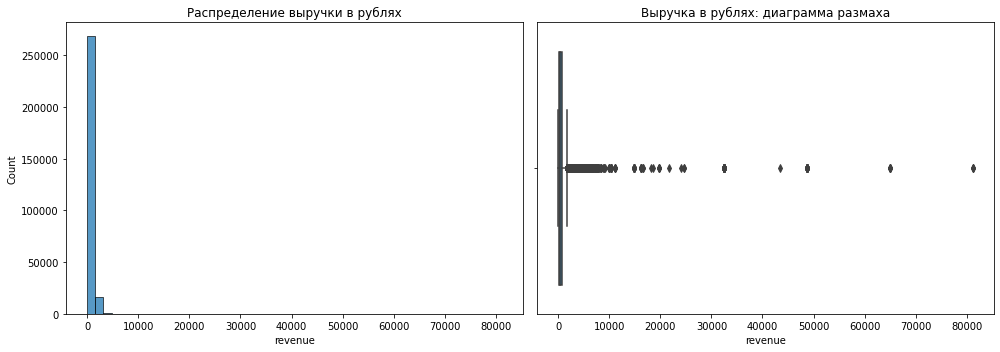

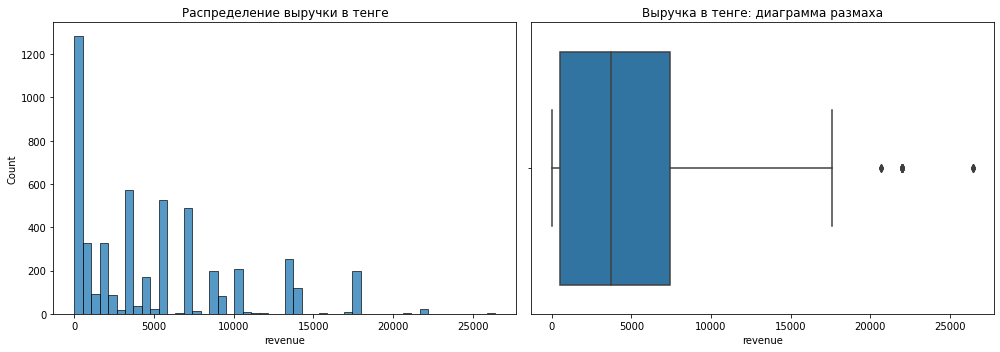

In [10]:
# Разделяем данные по валютам
df_rub = df[df['currency_code'] == 'rub'].copy()
df_kzt = df[df['currency_code'] == 'kzt'].copy()

# Смотрим распределения отдельно по рублям
fig, ax = plt.subplots(1, 2, figsize=(14, 5))

sns.histplot(df_rub['revenue'], bins=50, ax=ax[0])
ax[0].set_title('Распределение выручки в рублях')

sns.boxplot(x=df_rub['revenue'], ax=ax[1])
ax[1].set_title('Выручка в рублях: диаграмма размаха')

plt.tight_layout()
plt.show()

# Смотрим распределения отдельно по тенге
fig, ax = plt.subplots(1, 2, figsize=(14, 5))

sns.histplot(df_kzt['revenue'], bins=50, ax=ax[0])
ax[0].set_title('Распределение выручки в тенге')

sns.boxplot(x=df_kzt['revenue'], ax=ax[1])
ax[1].set_title('Выручка в тенге: диаграмма размаха')

plt.tight_layout()
plt.show()

In [11]:
# Удаляем выбросы отдельно в каждой валюте по 99-му процентилю
rub_99 = df_rub['revenue'].quantile(0.99)
kzt_99 = df_kzt['revenue'].quantile(0.99)

df_rub = df_rub[df_rub['revenue'] <= rub_99].copy()
df_kzt = df_kzt[df_kzt['revenue'] <= kzt_99].copy()

# Объединяем обратно
df = pd.concat([df_rub, df_kzt], ignore_index=True)

print('Размер датасета после удаления выбросов:', df.shape)

Размер датасета после удаления выбросов: (287932, 24)


In [12]:
# Готовим таблицу курса тенге к рублю
# В датасете курс указан для 100 тенге, поэтому делим на 100
tenge = tenge.sort_values('data').copy()
tenge['kzt_to_rub_per_1'] = tenge['curs'] / 100
tenge = tenge[['data', 'kzt_to_rub_per_1']]

# Добавляем дату заказа для объединения с курсом
df['date'] = df['created_dt_msk'].dt.normalize()

# Объединяем с курсом валют
df = df.merge(tenge, left_on='date', right_on='data', how='left')

# Приводим выручку к рублям
df['revenue_rub'] = np.where(
    df['currency_code'] == 'rub',
    df['revenue'],
    df['revenue'] * df['kzt_to_rub_per_1']
)

# Считаем выручку с одного билета
df['one_ticket_revenue_rub'] = df['revenue_rub'] / df['tickets_count']

# Выделяем месяц и сезон
df['month'] = df['created_dt_msk'].dt.month
df['season'] = df['month'].map({
    6: 'лето',
    7: 'лето',
    8: 'лето',
    9: 'осень',
    10: 'осень'
})

In [13]:
# Заполняем пропуски в основных категориальных столбцах
for col in ['event_type_main', 'region_name', 'city_name', 'service_name']:
    df[col] = df[col].fillna('не указано')

# Приводим типы к более экономным, если возможно
df['tickets_count'] = df['tickets_count'].astype('int16')
df['month'] = df['month'].astype('int8')

# Считаем долю удалённых строк
removed_rows = before_clean - len(df)
removed_share = removed_rows / before_clean * 100

# Смотрим итог после предобработки
display(df.head(5))
print('Итоговый размер данных:', df.shape)
print('Удалено строк:', removed_rows)
print(f'Доля удалённых строк: {removed_share:.2f}%')
print('Пропуски в days_since_prev:', df['days_since_prev'].isna().sum())

,order_id,user_id,created_dt_msk,created_ts_msk,event_id,cinema_circuit,age_limit,currency_code,device_type_canonical,revenue,...,venue_id,venue_name,venue_address,date,data,kzt_to_rub_per_1,revenue_rub,one_ticket_revenue_rub,month,season
0,4359165,0002849b70a3ce2,2024-08-20,2024-08-20 16:08:03,169230,NaN,16,rub,mobile,1521.94,...,3972.0,"Сценический центр ""Деталь"" Групп","алл. Машиностроителей, д. 19 стр. 6",2024-08-20,2024-08-20,0.186972,1521.94,380.4850,8,лето
1,7965605,0005ca5e93f2cf4,2024-07-23,2024-07-23 18:36:24,237325,NaN,0,rub,mobile,289.45,...,2941.0,"Музыкальная школа для детей ""Аккаунт"" Лтд","алл. Шмидта, д. 9 стр. 4",2024-07-23,2024-07-23,0.183419,289.45,144.7250,7,лето
2,7292370,0005ca5e93f2cf4,2024-10-06,2024-10-06 13:56:02,578454,NaN,0,rub,mobile,1258.57,...,4507.0,"Училище искусств ""Нирвана"" Инк","алл. Юбилейная, д. 5/6",2024-10-06,2024-10-06,0.196475,1258.57,314.6425,10,осень
3,1139875,000898990054619,2024-07-13,2024-07-13 19:40:48,387271,NaN,0,rub,mobile,8.49,...,3574.0,"Театр альтернативного искусства ""Ода"" Лимитед","алл. Есенина, д. 243 к. 3/8",2024-07-13,2024-07-13,0.185010,8.49,4.2450,7,лето
4,972400,000898990054619,2024-10-04,2024-10-04 22:33:15,509453,NaN,18,rub,mobile,1390.41,...,1896.0,"Театр кукол ""Огни"" Инкорпорэйтед","ш. Набережное, д. 595 стр. 8",2024-10-04,2024-10-04,0.196648,1390.41,463.4700,10,осень


Итоговый размер данных: (287932, 31)
Удалено строк: 2917
Доля удалённых строк: 1.00%
Пропуски в days_since_prev: 21733


### Результаты предобработки данных
На этапе предобработки данные были объединены, приведены к нужным типам, проверены на пропуски, дубликаты и аномальные значения. Выручка была очищена от выбросов, переведена в рубли, а также были созданы новые признаки: `revenue_rub`, `one_ticket_revenue_rub`, `month` и `season`.\
Итоговый размер данных **(287932, 31)**, доля удаленных строк после предобработки составляет **1 %**, пропуски в days_since_prev: 21522. Пропуски в days_since_prev допустимы, так как этот столбец показывает число дней с предыдущей покупки пользователя. Для первой покупки у каждого пользователя предыдущего заказа нет, поэтому разницу рассчитать невозможно, и в этих строках остаётся пропуск.

## 3. Исследовательский анализ данных по сезонам, дням и категориям
На данном этапе выполним исследовательский анализ по сезонам, дням и категориям. Построим необходимые визуализации.

,month,orders
0,6,34343
1,7,40410
2,8,44572
3,9,69333
4,10,99274


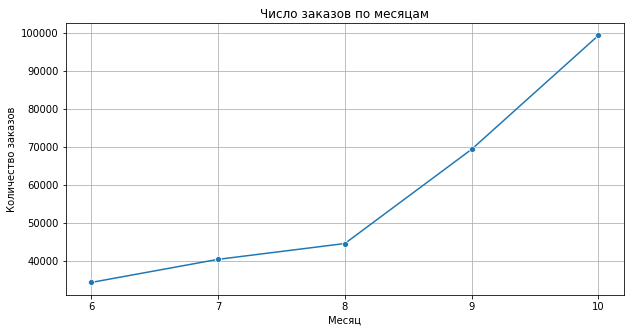

In [14]:
# Считаем число заказов по месяцам
monthly_orders = df.groupby('month').agg(orders=('order_id', 'nunique')).reset_index()

display(monthly_orders)

# Строим график динамики
plt.figure(figsize=(10, 5))
sns.lineplot(data=monthly_orders, x='month', y='orders', marker='o')
plt.title('Число заказов по месяцам')
plt.xlabel('Месяц')
plt.ylabel('Количество заказов')
plt.xticks([6, 7, 8, 9, 10])
plt.grid(True)
plt.show()

Из графика видно, что число заказов по увеличивается от месяца к месяцу: от `32845` в `июне 2024` до `99914`  в `октябре 2024`.

,season,event_type_main,orders,share
2,лето,концерты,50757,0.425368
1,лето,другое,32369,0.271268
6,лето,театр,23942,0.200645
5,лето,стендап,6346,0.053182
4,лето,спорт,3006,0.025192
0,лето,выставки,2416,0.020247
7,лето,ёлки,273,0.002288
3,лето,не указано,216,0.001810
10,осень,концерты,62694,0.371835
14,осень,театр,42735,0.253459


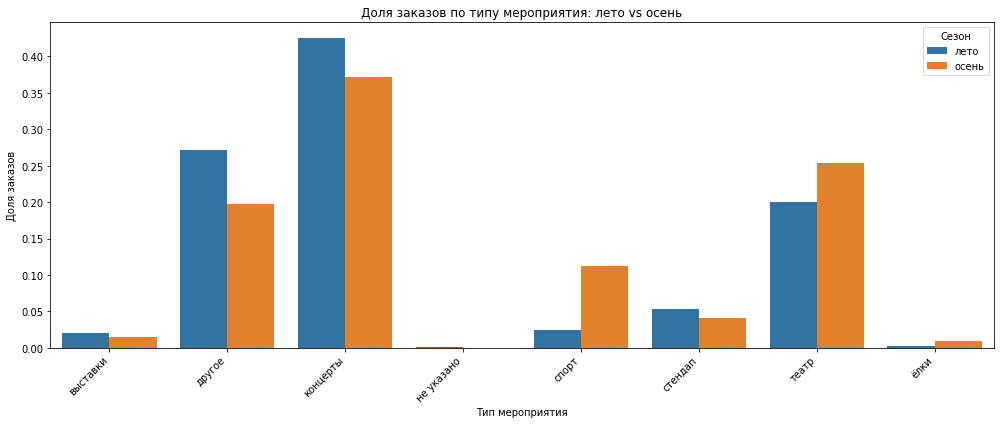

In [15]:
# Сравниваем лето и осень по типу мероприятия
season_event = df.groupby(['season', 'event_type_main']).agg(
    orders=('order_id', 'nunique')
).reset_index()

# Считаем долю каждой категории внутри сезона
season_event['share'] = season_event.groupby('season')['orders'].transform(lambda x: x / x.sum())

display(season_event.sort_values(['season', 'share'], ascending=[True, False]))

plt.figure(figsize=(14, 6))
sns.barplot(data=season_event, x='event_type_main', y='share', hue='season')
plt.title('Доля заказов по типу мероприятия: лето vs осень')
plt.xlabel('Тип мероприятия')
plt.ylabel('Доля заказов')
plt.xticks(rotation=45, ha='right')
plt.legend(title='Сезон')
plt.tight_layout()
plt.show()

#### Выводы по сезонности и типам событий

- **Концерты — лидер в оба сезона:**
  - Лето: 49 383 заказа (41.73%)
  - Осень: 63 333 заказа (37.34%)
  - При росте абсолютного числа заказов осенью, доля снижается на ~4.4 п.п.

- **Театр усиливается осенью:**
  - Лето: 24 128 (20.39%)
  - Осень: 42 986 (25.34%)
  - Рост доли: +4.95 п.п. и почти двукратный рост по количеству

- **Категория "другое" теряет долю:**
  - Лето: 32 526 (27.49%)
  - Осень: 33 285 (19.62%)
  - Почти без роста по объему, но падение доли на ~7.9 п.п.

- **Спорт — сильный сезонный рост:**
  - Лето: 3 010 (2.54%)
  - Осень: 18 887 (11.14%)
  - Рост доли более чем в 4 раза (+8.6 п.п.)

- **Стендап стабилен с небольшим снижением:**
  - Лето: 6 381 (5.39%)
  - Осень: 6 944 (4.09%)
  - Незначительный рост объема, но падение доли

- **Выставки снижают долю:**
  - Лето: 2 417 (2.04%)
  - Осень: 2 437 (1.44%)
  - Объем почти не меняется, но доля падает

- **Ёлки — ярко выраженная сезонность:**
  - Лето: 275 (0.23%)
  - Осень: 1 712 (1.01%)
  - Рост более чем в 6 раз, ожидаемый тренд перед зимой

- **"Не указано" практически исчезает осенью:**
  - Лето: 216 (0.18%)
  - Осень: 22 (0.01%)

##### Ключевые инсайты

- Осенью рынок становится более **диверсифицированным**: падает доминирование концертов и «другого».
- Основные драйверы роста осенью: **театр и спорт**.
- Лето более концентрировано вокруг **концертов и прочих событий (≈69%)**.
- Осенью растет значимость **структурированных категорий** (театр, спорт), что может говорить о более планируемом потреблении.

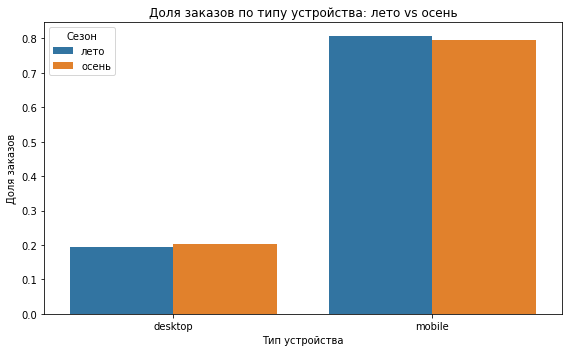

In [16]:
# Сравниваем сезоны по типу устройства
season_device = df.groupby(['season', 'device_type_canonical']).agg(
    orders=('order_id', 'nunique')
).reset_index()

season_device['share'] = season_device.groupby('season')['orders'].transform(lambda x: x / x.sum())

plt.figure(figsize=(8, 5))
sns.barplot(data=season_device, x='device_type_canonical', y='share', hue='season')
plt.title('Доля заказов по типу устройства: лето vs осень')
plt.xlabel('Тип устройства')
plt.ylabel('Доля заказов')
plt.legend(title='Сезон')
plt.tight_layout()
plt.show()

Из диаграммы видно, что доля заказов сделанных с устройств `mobile` и `desktop` практически не меняется осенью относительно лета.

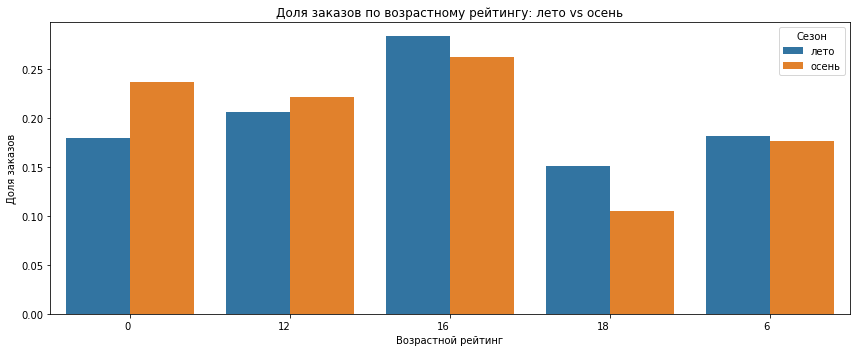

In [17]:
# Сравниваем сезоны по возрастному рейтингу
season_age = df.groupby(['season', 'age_limit']).agg(
    orders=('order_id', 'nunique')
).reset_index()

season_age['share'] = season_age.groupby('season')['orders'].transform(lambda x: x / x.sum())

plt.figure(figsize=(12, 5))
sns.barplot(data=season_age, x='age_limit', y='share', hue='season')
plt.title('Доля заказов по возрастному рейтингу: лето vs осень')
plt.xlabel('Возрастной рейтинг')
plt.ylabel('Доля заказов')
plt.xticks(rotation=0, ha='right')
plt.legend(title='Сезон')
plt.tight_layout()
plt.show()

Из диаграммы видно, что доля заказов по возрастному рейтингу `0` и `12` от лета к осени увеличивается, а `16`, `18` и `6`уменьшается.

,season,event_type_main,mean_ticket
0,лето,выставки,86.416198
1,лето,другое,77.433968
2,лето,концерты,304.717078
3,лето,не указано,3.611663
4,лето,спорт,50.761831
5,лето,стендап,218.518107
6,лето,театр,214.126333
7,лето,ёлки,271.436176
8,осень,выставки,90.603610
9,осень,другое,76.115334


season,event_type_main,лето,осень,change_pct
3,не указано,3.611663,15.055038,316.845057
5,стендап,218.518107,231.124973,5.769255
0,выставки,86.416198,90.603610,4.845634
4,спорт,50.761831,49.969733,-1.560421
1,другое,77.433968,76.115334,-1.702914
2,концерты,304.717078,268.084074,-12.021973
7,ёлки,271.436176,229.585589,-15.418205
6,театр,214.126333,175.969508,-17.819772


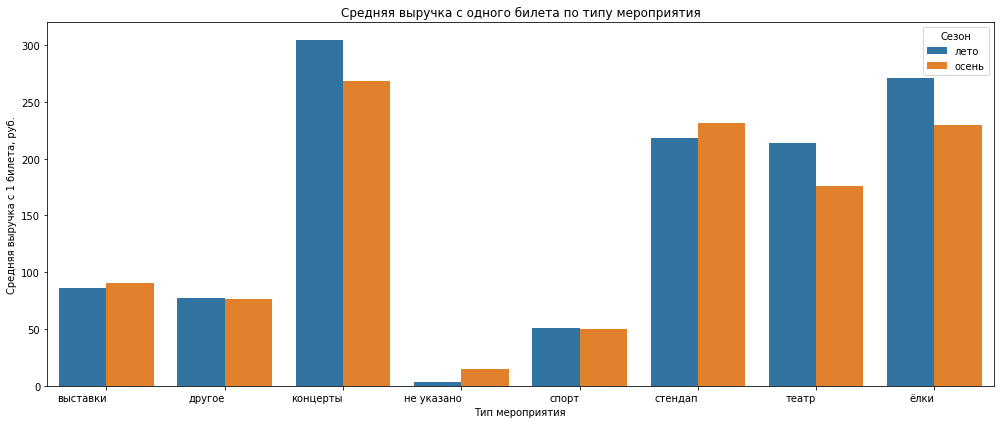

In [18]:
# Считаем среднюю выручку с одного билета по типам мероприятий
ticket_price = df.groupby(['season', 'event_type_main']).agg(
    mean_ticket=('one_ticket_revenue_rub', 'mean')
).reset_index()

display(ticket_price)

# Сравниваем осень и лето в процентах
pivot = ticket_price.pivot(index='event_type_main', columns='season', values='mean_ticket').reset_index()
pivot['change_pct'] = (pivot['осень'] / pivot['лето'] - 1) * 100

display(pivot.sort_values('change_pct', ascending=False))

plt.figure(figsize=(14, 6))
sns.barplot(data=ticket_price, x='event_type_main', y='mean_ticket', hue='season')
plt.title('Средняя выручка с одного билета по типу мероприятия')
plt.xlabel('Тип мероприятия')
plt.ylabel('Средняя выручка с 1 билета, руб.')
plt.xticks(rotation=0, ha='right')
plt.legend(title='Сезон')
plt.tight_layout()
plt.show()

По средней выручке с одного билета летом лидировали **концерты** — 297.3 руб., **ёлки** — 274.7 руб. и **театр** — 218.7 руб. Осенью картина изменилась: на первом месте остались **концерты**, но средний чек снизился до 273.8 руб., у **ёлок** показатель упал до 234.2 руб., а у **театра** — до 179.7 руб.

При этом некоторые категории показали рост осенью. Средняя выручка с одного билета у **выставок** увеличилась с 86.4 до 91.1 руб. (+5.4%), а у **стендапа** — с 221.3 до 232.6 руб. (+5.1%). Также почти не изменилась категория **спорт**: 52.0 руб. летом и 50.0 руб. осенью.

Наибольшее снижение среднего чека наблюдается у **театра** — на 17.8%, и у **ёлок** — на 14.8%. В целом осенью средняя стоимость билета снизилась в большинстве популярных категорий, особенно в культурно-развлекательных событиях.

In [19]:
# Берём только осень
autumn = df[df['season'] == 'осень'].copy()

# Собираем дневную статистику
daily = autumn.groupby(autumn['created_dt_msk'].dt.date).agg(
    orders=('order_id', 'nunique'),
    users=('user_id', 'nunique'),
    mean_ticket=('one_ticket_revenue_rub', 'mean')
).reset_index().rename(columns={'created_dt_msk': 'date'})

# Считаем заказы на пользователя
daily['orders_per_user'] = daily['orders'] / daily['users']

display(daily.head())

,date,orders,users,mean_ticket,orders_per_user
0,2024-09-01,1327,564,200.168708,2.352837
1,2024-09-02,1380,574,189.464639,2.404181
2,2024-09-03,5111,778,80.130097,6.569409
3,2024-09-04,1773,685,177.685576,2.588321
4,2024-09-05,1944,739,189.510156,2.630582


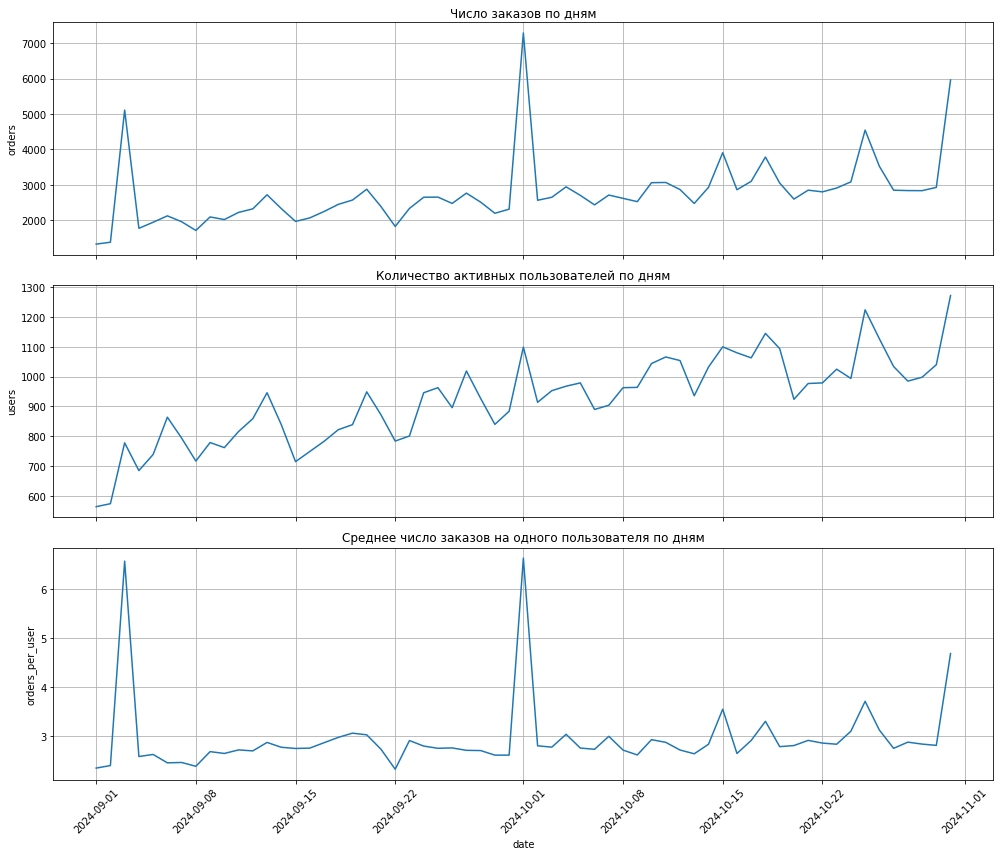

In [20]:
# Строим динамику по дням
fig, ax = plt.subplots(3, 1, figsize=(14, 12), sharex=True)

sns.lineplot(data=daily, x='date', y='orders', ax=ax[0])
ax[0].set_title('Число заказов по дням')

sns.lineplot(data=daily, x='date', y='users', ax=ax[1])
ax[1].set_title('Количество активных пользователей по дням')

sns.lineplot(data=daily, x='date', y='orders_per_user', ax=ax[2])
ax[2].set_title('Среднее число заказов на одного пользователя по дням')

for a in ax:
    a.grid(True)

plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

В начале осени 2024 года дневная активность заметно колебалась. 1 сентября было оформлено **1 346 заказов** от **569 пользователей**, а средний чек составил **206.7 руб.**; при этом на одного пользователя приходилось **2.37 заказа**.

Пик активности в приведённом фрагменте пришёлся на **3 сентября**: было оформлено **5 112 заказов** от **778 пользователей**, а число заказов на одного пользователя достигло **6.57**, **1 октября** и **1 ноября**. При этом средний чек в этот день был одним из самых низких — **81.0 руб.**, что может указывать на массовые недорогие покупки.

В целом по этим дням видно, что рост числа заказов не всегда сопровождается ростом среднего чека. Динамика показывает, что пользовательская активность и стоимость одного билета изменяются независимо и могут сильно отличаться от дня к дню.

,weekday,orders,users,avg_ticket
0,Monday,21517,4448,184.081657
1,Tuesday,31480,4793,140.496802
2,Wednesday,22888,4813,185.685146
3,Thursday,27169,4970,177.888277
4,Friday,24828,4870,185.542069
5,Saturday,21336,4571,192.079949
6,Sunday,19389,4394,197.921015


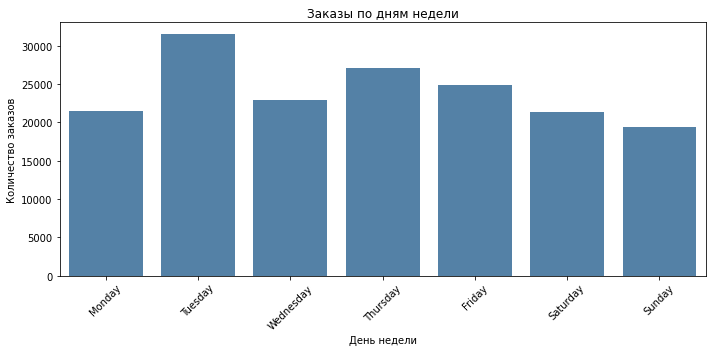

In [21]:
# Добавляем день недели
autumn['weekday'] = autumn['created_dt_msk'].dt.day_name()

# Задаём правильный порядок дней
weekday_order = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']
autumn['weekday'] = pd.Categorical(autumn['weekday'], categories=weekday_order, ordered=True)

# Считаем показатели по дням недели
weekday = autumn.groupby('weekday').agg(
    orders=('order_id', 'nunique'),
    users=('user_id', 'nunique'),
    avg_ticket=('one_ticket_revenue_rub', 'mean')
).reset_index()

display(weekday)

plt.figure(figsize=(10, 5))
sns.barplot(data=weekday, x='weekday', y='orders', color='steelblue')
plt.title('Заказы по дням недели')
plt.xlabel('День недели')
plt.ylabel('Количество заказов')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

Наибольшее **количество заказов** приходится на **вторник** — 31 653, что на 46% больше, чем в понедельник (21 649). Это пик активности по объему.\
Максимальное **количество пользователей** также наблюдается в **четверг** — 4 977, при этом вторник (4 799) и пятница (4 876) показывают сопоставимые значения.\
Самый высокий **средний чек** зафиксирован в **воскресенье** — 201.42, что на ~40% выше, чем во вторник (144.23), где средний чек минимален.\
Выходные (суббота и воскресенье) характеризуются меньшим количеством заказов (21 469 и 19 509 соответственно), но более высоким средним чеком (195.83 и 201.42), что может указывать на более “дорогие” покупки.\
В будние дни (особенно вторник и четверг) наблюдается высокий объем заказов при относительно низком среднем чеке (144.23–180.70), что может говорить о более частых, но менее дорогих транзакциях.\
Понедельник выделяется низким количеством пользователей (4 461) и заказов, но средний чек остается на уровне выше вторника — 187.83.\
В целом прослеживается обратная зависимость: при росте количества заказов средний чек снижается (например, вторник vs воскресенье).

In [22]:
# Сводка по регионам
regions = autumn.groupby('region_name').agg(
    events=('event_id', 'nunique'),
    orders=('order_id', 'nunique'),
    revenue=('revenue_rub', 'sum')
).reset_index()

regions['event_share'] = regions['events'] / regions['events'].sum()
regions['order_share'] = regions['orders'] / regions['orders'].sum()

display(regions.sort_values('orders', ascending=False).head(10))

,region_name,events,orders,revenue,event_share,order_share
23,Каменевский регион,3910,46684,2.860734e+07,0.246222,0.276881
59,Североярская область,2613,20718,1.053250e+07,0.164547,0.122877
41,Медовская область,369,12044,2.343986e+06,0.023237,0.071432
75,Широковская область,803,8715,4.227784e+06,0.050567,0.051688
44,Озернинский край,296,7480,6.632991e+06,0.018640,0.044364
56,Светополянский округ,764,4779,1.987402e+06,0.048111,0.028344
60,Серебринская область,456,4467,1.562719e+06,0.028715,0.026494
40,Малиновоярский округ,137,4412,3.365825e+06,0.008627,0.026167
63,Солнечноземская область,403,4228,8.627110e+05,0.025378,0.025076
76,Яблоневская область,432,4199,1.943528e+06,0.027204,0.024904


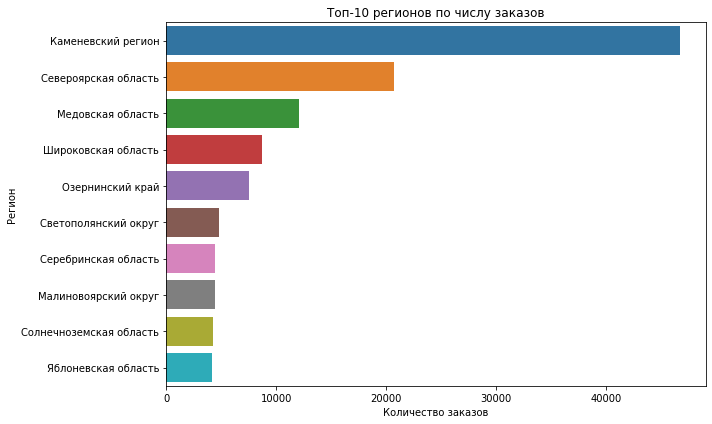

In [23]:
# Топ регионов по числу заказов
top_regions = regions.sort_values('orders', ascending=False).head(10)

plt.figure(figsize=(10, 6))
sns.barplot(data=top_regions, x='orders', y='region_name')
plt.title('Топ-10 регионов по числу заказов')
plt.xlabel('Количество заказов')
plt.ylabel('Регион')
plt.tight_layout()
plt.show()



По данным за осень 2024 года по регионам заметен выраженный лидер — **Каменевский регион**. На него приходится **39 030 мероприятий**, **47 271 заказ** и **30.38 млн руб. выручки**, что составляет **24.7%** всех мероприятий и **27.9%** всех заказов в выборке.

На втором месте находится **Североярская область**: **2 620 мероприятий**, **20 855 заказов** и **10.93 млн руб. выручки**; её доля по заказам составляет **12.3%**. Далее идут **Медовская область** с **12 052 заказами** и **2.36 млн руб.**, а также **Широковская область** с **8 739 заказами** и **4.29 млн руб.**.

При этом у некоторых регионов доля заказов заметно выше, чем доля мероприятий. Например, **Озернинский край** дал только **1.9%** мероприятий, но обеспечил **4.5%** заказов и **6.91 млн руб. выручки**. Это говорит о том, что вклад регионов в спрос определяется не только количеством событий, но и их востребованностью.

В целом распределение неравномерное: основная часть заказов и выручки сосредоточена в нескольких крупных регионах, прежде всего в Каменевском регионе и Североярской области.

In [24]:
# Сводка по билетным партнёрам
partners = autumn.groupby('service_name').agg(
    events=('event_id', 'nunique'),
    orders=('order_id', 'nunique'),
    revenue=('revenue_rub', 'sum')
).reset_index()

display(partners.sort_values('orders', ascending=False).head(15))

,service_name,events,orders,revenue
3,Билеты без проблем,2847,32383,1.211601e+07
21,Лови билет!,3616,25792,1.037679e+07
5,Билеты в руки,2471,25734,7.613966e+06
24,Мой билет,1006,19419,1.085081e+07
25,Облачко,1409,15478,1.061105e+07
22,Лучшие билеты,1397,12445,1.676010e+06
8,Весь в билетах,599,9406,9.325571e+06
26,Прачечная,728,5798,2.548310e+06
30,Тебе билет!,859,3749,2.137900e+06
34,Яблоко,537,3473,2.763332e+06


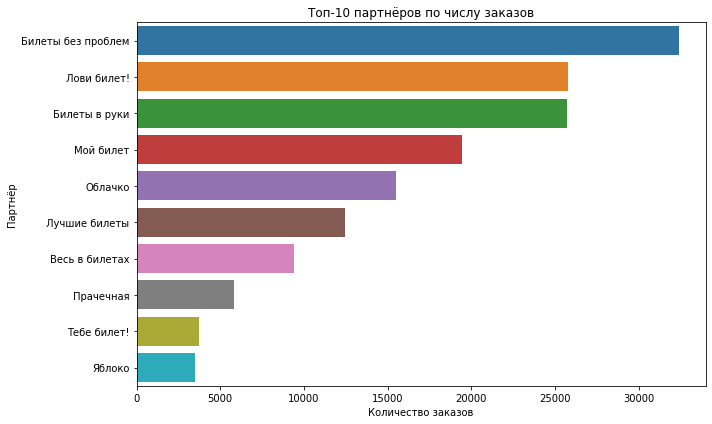

In [25]:
# Топ партнёров по числу заказов
top_partners = partners.sort_values('orders', ascending=False).head(10)

plt.figure(figsize=(10, 6))
sns.barplot(data=top_partners, x='orders', y='service_name')
plt.title('Топ-10 партнёров по числу заказов')
plt.xlabel('Количество заказов')
plt.ylabel('Партнёр')
plt.tight_layout()
plt.show()

По данным за осень 2024 года среди билетных партнёров выделяются несколько явных лидеров по числу заказов и выручке. Наибольшее количество заказов обработали **«Билеты без проблем»** — 32 539 заказов и 12.82 млн руб., **«Лови билет!»** — 25 862 заказа и 10.57 млн руб., а также **«Билеты в руки»** — 25 762 заказа и 7.69 млн руб.

При этом по выручке заметны и партнёры с меньшим числом заказов, но более высоким средним чеком. Например, **«Мой билет»** при 19 563 заказах принёс 11.39 млн руб., а **«Облачко»** при 15 572 заказах — 10.89 млн руб.

В целом распределение неравномерное: основная часть спроса и выручки сосредоточена у нескольких крупнейших партнёров, тогда как остальные сервисы значительно уступают лидерам по масштабу.

## 4. Статистическая проверка гипотез
Фильтрация по времени года (осень) и типу устройства (`mobile` и `desktop`). Формулирование гипотез и их статистическая проверка.

In [26]:
#Проверяем на пересечение клиентов в группах
# Берём осень
autumn = df[df['season'] == 'осень'].copy()

# Делим на группы
mobile = autumn[autumn['device_type_canonical'] == 'mobile'].copy()
desktop = autumn[autumn['device_type_canonical'] == 'desktop'].copy()

# Ищем пересечение пользователей
common_users = set(mobile['user_id']).intersection(set(desktop['user_id']))

# Считаем количество пересечений
common_users_count = len(common_users)

print(f'Пользователей, попавших в обе группы: {common_users_count}')

# Удаляем пересекающихся пользователей
mobile = mobile[~mobile['user_id'].isin(common_users)].copy()
desktop = desktop[~desktop['user_id'].isin(common_users)].copy()

print(f'Удалено пользователей из каждой группы: {common_users_count}')
print(f'Размер mobile после очистки: {mobile.shape}')
print(f'Размер desktop после очистки: {desktop.shape}')

Пользователей, попавших в обе группы: 3250
Удалено пользователей из каждой группы: 3250
Размер mobile после очистки: (31272, 31)
Размер desktop после очистки: (3197, 31)


In [27]:
# Оставляем только осень
mobile = autumn[autumn['device_type_canonical'] == 'mobile']
desktop = autumn[autumn['device_type_canonical'] == 'desktop']

# Считаем число заказов на пользователя в каждой группе
mobile_orders_per_user = mobile.groupby('user_id')['order_id'].nunique()
desktop_orders_per_user = desktop.groupby('user_id')['order_id'].nunique()

# Смотрим описательную статистику
print('Mobile:')
display(mobile_orders_per_user.describe())

print('Desktop:')
display(desktop_orders_per_user.describe())

Mobile:


count    14190.000000
mean         9.464693
std         68.055516
min          1.000000
25%          1.000000
50%          2.000000
75%          5.000000
max       4336.000000
Name: order_id, dtype: float64

Desktop:


count    4869.000000
mean        7.045184
std        35.987490
min         1.000000
25%         1.000000
50%         2.000000
75%         4.000000
max      1502.000000
Name: order_id, dtype: float64

#### Формулируем Гипотезу 1:
$H_0$: Среднее количество заказов на одного пользователя мобильного приложения **не** выше по сравнению с пользователями стационарных устройств.

$H_1$: Среднее количество заказов на одного пользователя мобильного приложения выше по сравнению с пользователями стационарных устройств.

In [33]:
# Гипотеза 1:
# H0 — среднее число заказов на пользователя у мобильных и стационарных пользователей не отличается.
# H1 — у мобильных пользователей среднее число заказов выше.

stat1, p_value1 = stats.mannwhitneyu(
    mobile_orders_per_user,
    desktop_orders_per_user,
    alternative='greater'
)

alpha = 0.05

print(f'Гипотеза 1: статистика = {stat1:.1f}, p-value = {p_value1:.2e}')

if p_value1 < alpha:
    print(
        'p-value меньше уровня значимости 0.05, поэтому нулевую гипотезу отвергаем. '
        'Есть статистически значимые основания считать, что среднее число заказов на одного пользователя '
        'у мобильных пользователей выше, чем у пользователей стационарных устройств.'
    )
else:
    print(
        'p-value не меньше уровня значимости 0.05, поэтому оснований отвергать нулевую гипотезу нет. '
        'Статистически значимых различий между группами не выявлено.'
    )

Гипотеза 1: статистика = 36121272.5, p-value = 3.40e-07
p-value меньше уровня значимости 0.05, поэтому нулевую гипотезу отвергаем. Есть статистически значимые основания считать, что среднее число заказов на одного пользователя у мобильных пользователей выше, чем у пользователей стационарных устройств.


In [29]:
# Считаем интервалы между заказами в обеих группах
mobile_gaps = mobile.sort_values(['user_id', 'created_dt_msk']).groupby('user_id')['created_dt_msk'].diff().dt.days.dropna()
desktop_gaps = desktop.sort_values(['user_id', 'created_dt_msk']).groupby('user_id')['created_dt_msk'].diff().dt.days.dropna()

print('Mobile gaps:')
display(mobile_gaps.describe())

print('Desktop gaps:')
display(desktop_gaps.describe())

Mobile gaps:


count    120114.000000
mean          1.620402
std           4.998285
min           0.000000
25%           0.000000
50%           0.000000
75%           1.000000
max          60.000000
Name: created_dt_msk, dtype: float64

Desktop gaps:


count    29434.000000
mean         1.847659
std          5.515208
min          0.000000
25%          0.000000
50%          0.000000
75%          1.000000
max         60.000000
Name: created_dt_msk, dtype: float64

#### Формулируем Гипотезу 2:
$H_0$: Среднее время между заказами у пользователей мобильного приложения **не** выше по сравнению с пользователями стационарных устройств.

$H_1$: Среднее время между заказами у пользователей мобильного приложения выше по сравнению с пользователями стационарных устройств.

In [30]:
# Гипотеза 2:
# H0 — среднее время между заказами у мобильных и стационарных пользователей не отличается.
# H1 — у мобильных пользователей среднее время между заказами выше.

stat2, p_value2 = stats.mannwhitneyu(
    mobile_gaps,
    desktop_gaps,
    alternative='greater'
)

print('Статистика:', stat2)
print('p-value:', p_value2)

alpha = 0.05

print(f'Гипотеза 2: статистика = {stat2:.1f}, p-value = {p_value2:.10f}')

if p_value2 < alpha:
    print(
        'p-value меньше уровня значимости 0.05, поэтому нулевую гипотезу отвергаем. '
        'Есть статистически значимые основания считать, что среднее время между заказами '
        'у мобильных пользователей выше, чем у пользователей стационарных устройств.'
    )
else:
    print(
        'p-value больше уровня значимости 0.05, поэтому оснований отвергать нулевую гипотезу нет. '
        'Статистически значимых различий во времени между заказами у мобильных и стационарных пользователей не выявлено.'
    )

Статистика: 1756524512.0
p-value: 0.9826251572506236
Гипотеза 2: статистика = 1756524512.0, p-value = 0.9826251573
p-value больше уровня значимости 0.05, поэтому оснований отвергать нулевую гипотезу нет. Статистически значимых различий во времени между заказами у мобильных и стационарных пользователей не выявлено.


Для проверки гипотез выбираем **U-критерий Манна — Уитни**, так как сравниваются две **независимые** выборки: пользователи мобильных устройств и пользователи стационарных устройств. Показатели, которые анализируются, являются количественными, а распределение может отличаться от нормального, поэтому непараметрический тест подходит лучше, чем t-критерий Стьюдента.

## 5. Выводы и рекомендации


В анализе использовались данные о заказах билетов за период с июня по октябрь 2024 года, а также справочник событий и курс тенге к рублю.
После предобработки данные были объединены, очищены от выбросов по выручке, приведены к единой валюте и дополнены новыми признаками: `revenue_rub`, `one_ticket_revenue_rub`, `month`, `season`.

За период наблюдения число заказов выросло с **32 845** в июне до **99 914** в октябре, что говорит об усилении спроса к осени.
Осенью структура спроса изменилась:
- доля **концертов** снизилась, хотя они остались крупнейшей категорией;
- заметно выросли **театр** и **спорт**;
- категория **ёлки** показала ярко выраженную сезонность и выросла перед зимой;
- средняя стоимость билета в большинстве популярных категорий снизилась, особенно в театре и на ёлках.
- Пользовательская активность осенью была неравномерной по дням.
- По дневной динамике видно, что рост числа заказов не всегда сопровождался ростом среднего чека.
По неделе:
- максимум заказов приходился на **вторник**;
- в выходные средний чек был выше, чем в будни;
- это может означать, что в будние дни пользователи чаще совершают более частые и менее дорогие покупки, а в выходные — более дорогие.

По регионам лидирует **Каменевский регион**, затем **Североярская область**.
По партнёрам в лидерах **«Билеты без проблем»**, **«Лови билет!»** и **«Билеты в руки»**.
При этом некоторые регионы и партнёры дают заметную выручку даже при меньшем числе заказов, что говорит о разной ценности трафика и разной структуре спроса.

##### Проверка гипотез

- **Гипотеза 1 подтвердилась**: у пользователей мобильных устройств среднее число заказов на одного пользователя выше, чем у пользователей стационарных устройств.
- Это статистически значимо: `p-value = 3.404e-07`, что намного меньше 0.05.
- Значит, мобильные пользователи действительно активнее в части частоты заказов.

- **Гипотеза 2 не подтвердилась**: статистически значимых различий во времени между заказами у мобильных и стационарных пользователей нет.
- `p-value = 0.9826`, то есть оснований отвергать нулевую гипотезу нет.
- Это означает, что частота заказов у мобильных пользователей выше, но интервал между заказами в целом сопоставим с десктопными пользователями.

##### Рекомендации бизнесу

- Усиливать продвижение осенью для категорий с растущим спросом, прежде всего для **театра** и **спорта**.
- Отдельно развивать сезонные кампании под **ёлки** и другие предзимние события, так как у них есть выраженный пик спроса.
- Сфокусироваться на крупнейших регионах и партнёрах, но дополнительно проверить регионы и сервисы с высокой долей заказов при меньшем числе событий — там может быть высокий потенциал.
- Для мобильных пользователей развивать сценарии повторных покупок, так как именно они совершают больше заказов на пользователя.
- Для выхода на более высокий средний чек стоит изучить выходные дни и категории с дорогими билетами, а затем тестировать персональные предложения и рекомендации.